In [1]:
import geopandas as gpd 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import shapely 

### Testing the Distibution of dFADs

- Notebook which goes through and tests where the dFADs are distibuted 
- defines a function to make the heatmaps,
- test differernt bin sizes 

In [ ]:
data = gpd.read_file(r"C:\FATE\Palmyra FAD Watch GIS data for NASA (Nov 2024)-selected\MI_and_SAT_FAD_positions")
lines = data["geometry"]

In [5]:
points = np.empty((1,2))
for n in range(0,len(lines)):
    dummyline = lines[n]
    cords  = np.array(dummyline.coords)
    points = np.append(points,cords, axis= 0 )

rotatedpoints = np.rot90(points)
print(rotatedpoints.shape) ##this gives us all of lats in first row and all of the lon in second row

(2, 105310)


In [6]:

lat  = rotatedpoints[0][1:]
lon = rotatedpoints[1][1:]

In [25]:
##getting histogram data 

gridded, lonedges, latedges  = np.histogram2d(lon,lat,bins = 100)
gridded = gridded.T ##maybe need to transpose this data???


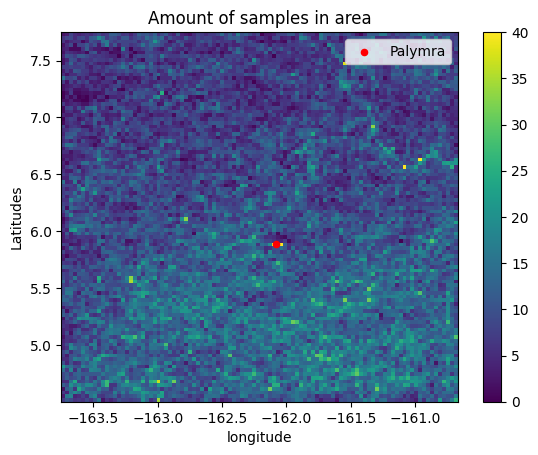

In [28]:
fig, ax = plt.subplots()
##ax.imshow(gridded)
##X, Y = np.meshgrid(xedges, yedges)
X, Y = np.meshgrid(lonedges, latedges)
cbr = ax.pcolormesh(X,Y,gridded)
ax.set_xlabel("longitude")
ax.set_ylabel("Latitudes")
ax.set_title("Amount of samples in area")
ax.scatter(-162.078333, 5.883611,  s = 20,color = "r", label = "Palymra")
ax.legend()
fig.colorbar(cbr)
cbr.set_clim(0,40)


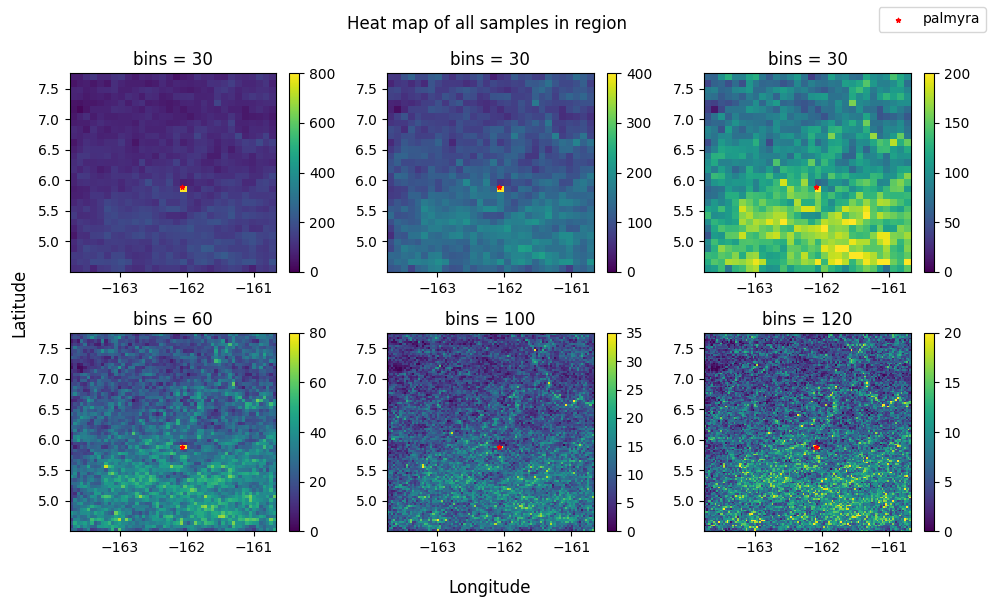

In [57]:
def makeheatmap(nbins,clim,a,b):
    gridded, lonedges, latedges  = np.histogram2d(lon,lat,bins = nbins)
    gridded = gridded.T ##maybe need to transpose this data???
    X, Y = np.meshgrid(lonedges, latedges)
    cbr = ax[a,b].pcolormesh(X,Y,gridded)
    ##ax[a,b].set_xlabel("longitude")
    ##ax[a,b].set_ylabel("Latitudes")
    ax[a,b].set_title(f"bins = {nbins}")
    line = ax[a,b].scatter(-162.078333, 5.883611,  s = 10,color = "r", marker = "*", alpha = 1)
    fig.colorbar(cbr, ax = ax[a,b])
    cbr.set_clim(0,clim)
    return line
    
    


fig, ax = plt.subplots(2,3,figsize = (10,6))
palmyra = makeheatmap(30,800,0,0)
makeheatmap(30,400,0,1)
makeheatmap(30,200,0,2)
makeheatmap(60,80,1,0)
makeheatmap(100,35,1,1)
makeheatmap(120,20,1,2)
fig.suptitle("Heat map of all samples in region ")
fig.supxlabel( "Longitude")
fig.supylabel( "Latitude")
fig.legend([palmyra],["palmyra"])
fig.tight_layout()



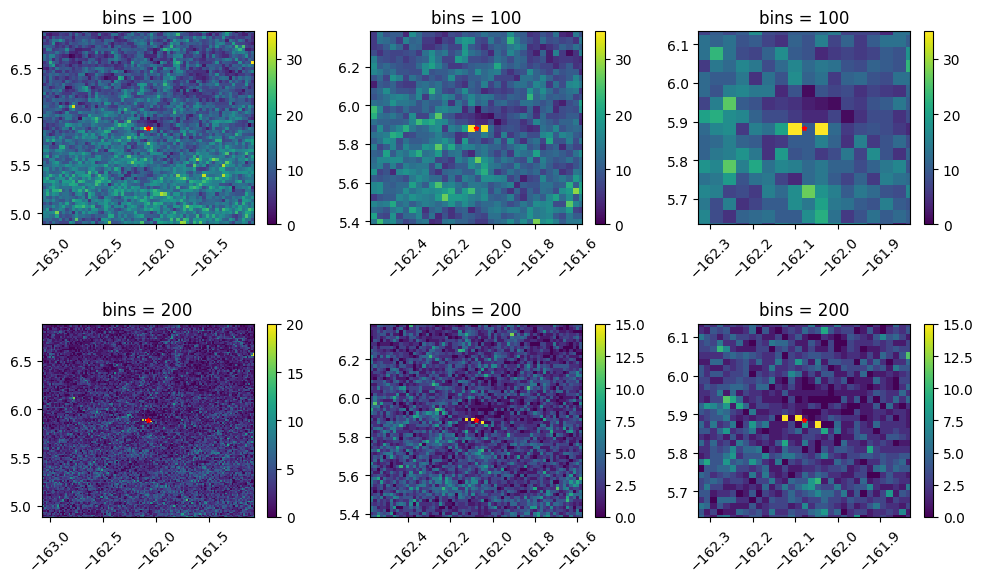

In [67]:
palmyra_cords = [-162.078333, 5.883611]
def heatmapzoom(d,a,b):
    ax[a,b].set_xlim(palmyra_cords[0]-d, palmyra_cords[0]+d)
    ax[a,b].set_ylim(palmyra_cords[1]-d, palmyra_cords[1]+d)
    ax[a,b].tick_params(axis='x', labelrotation=45)

fig, ax = plt.subplots(2,3, figsize = (10,6))
makeheatmap(100,35,0,0)
heatmapzoom(1,0,0)
makeheatmap(100,35,0,1)
heatmapzoom(0.5,0,1)
makeheatmap(100,35,0,2)
heatmapzoom(0.25,0,2)
makeheatmap(200,20,1,0)
heatmapzoom(1,1,0)
makeheatmap(200,15,1,1)
heatmapzoom(0.5,1,1)
makeheatmap(200,15,1,2)
heatmapzoom(0.25,1,2)
fig.tight_layout()